[Font] 未找到中文字体，中文可能显示为方框
检测到 Google Drive，结果将保存至: /content/drive/MyDrive/实验16_3_学习型重建
使用设备: cuda
加载MNIST数据...
MRI掩码: 加速因子R=4, 保留8/28行

步骤1：UNet后处理训练（16.4.1节）
  ↳ 检测到已有checkpoint，从第 20 轮继续训练
  UNet 模型已训练完毕，跳过。

步骤2：Learned Gradient Descent训练（16.4.2节）
  ↳ 检测到已有checkpoint，从第 15 轮继续训练
  LGD Epoch 20/20, Loss=0.0006
  ✓ checkpoint已保存 (epoch 20)
  LGD Block 0: alpha=0.5768
  LGD Block 1: alpha=0.2120
  LGD Block 2: alpha=0.7522
  LGD Block 3: alpha=1.0188
  LGD Block 4: alpha=0.9652

  参数量对比:
  UNet后处理: 131,953
  LGD每块:   75,650
  LGD总计(K=5): 378,250
  LGD总计 / UNet = 2.9× (≈K=5×)

步骤3：方法对比（16.4节总结）
  零填充:  PSNR=10.8±1.7dB
  UNet:    PSNR=26.2±2.7dB
  LGD:     PSNR=32.7±3.7dB


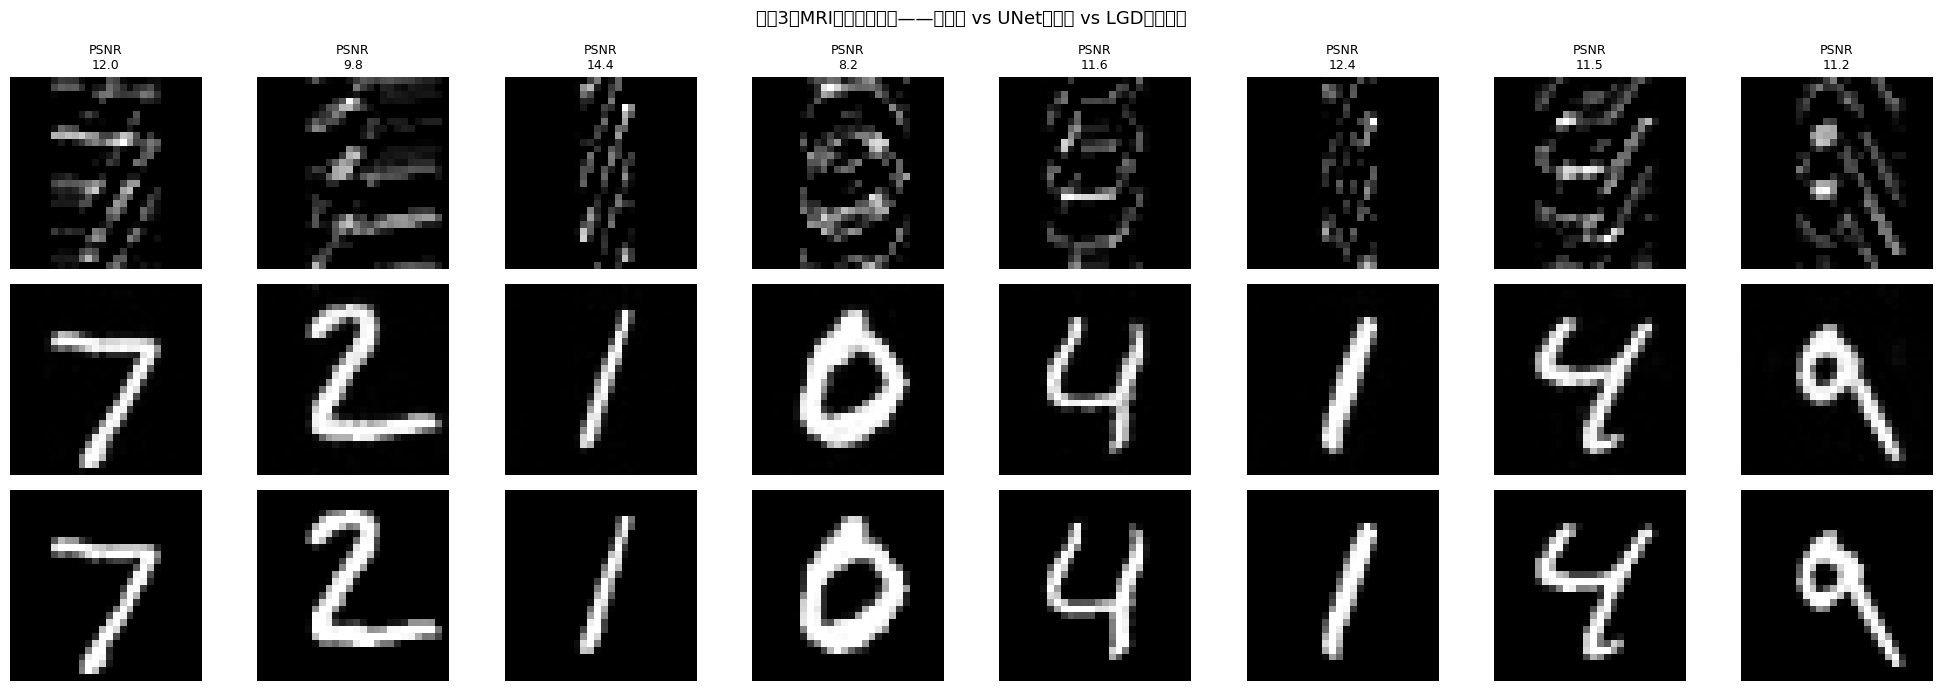

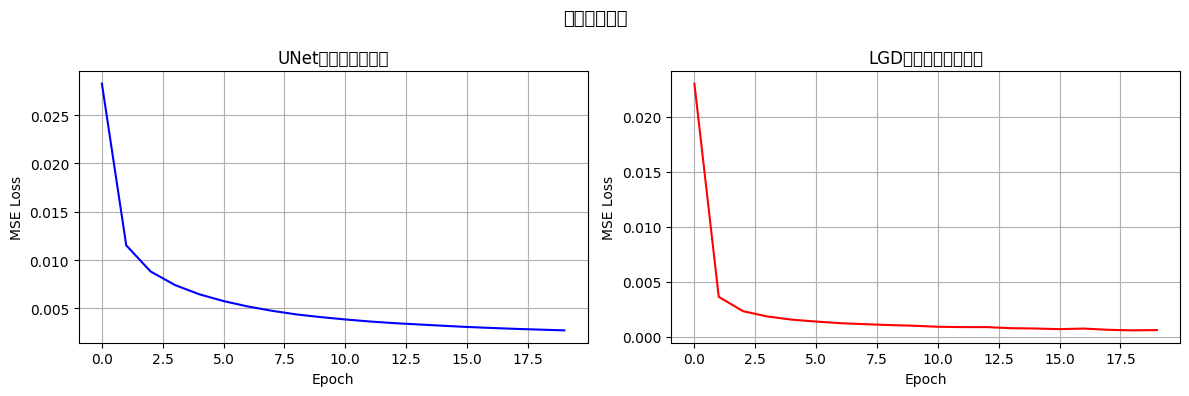


实验16.3完成！


In [1]:
# -*- coding: utf-8 -*-
"""
实验16.3 学习型重建——UNet后处理与算法展开
对应知识点：16.4.1节（UNet端到端重建）、16.4.2节（算法展开：LGD）

★原创设计：
- 使用MRI正向算子（FFT+掩码）替代ASTRA，跨平台兼容
- 在MNIST上训练UNet后处理和LGD
- MRI算子结构简单（F^H F = I），数据一致性步高效

素材来源：SmallUNet架构复用自11.2.py/15.2.py
运行前提：需GPU
"""

import os, sys, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码（Windows + Linux 自动适配）======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    """自动检测系统中可用的中文字体，兼容 Windows / Linux"""
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = [
            'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',
            'Noto Sans CJK SC', 'Noto Sans CJK',
            'Source Han Sans SC', 'AR PL UMing CN', 'SimHei',
        ]
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os as _os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (_os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

_gdrive = '/content/drive/MyDrive'
if os.path.isdir(_gdrive):
    SAVE_DIR = os.path.join(_gdrive, '实验16_3_学习型重建')
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"检测到 Google Drive，结果将保存至: {SAVE_DIR}")
else:
    SAVE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
    print(f"本地环境，结果将保存至: {SAVE_DIR}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")


# ========================================================================
# MRI正向算子定义
# ========================================================================
class MRIFourierOperator:
    """MRI欠采样傅里叶算子: A = M_Ω * F, A^T = F^H * M_Ω^T

    注意：此处掩码沿行方向（dim=H）采样，是对真实MRI相位编码方向的简化模拟，
    教学用途下合理，勿与实际扫描仪采样方向混淆。
    """
    def __init__(self, mask):
        """mask: (H,) 1D采样掩码, 1=采样, 0=未采样"""
        self.mask = mask  # (H,)

    def A(self, x):
        """正向: y = M_Ω * F * x, x: (B, 1, H, W)"""
        B, C, H, W = x.shape
        kspace = torch.fft.fft2(x)
        mask_2d = self.mask.view(1, 1, H, 1).expand(B, C, H, W).to(x.device)
        return kspace * mask_2d

    def AT(self, y):
        """伴随: x = F^H * M_Ω^T * y, y: (B, 1, H, W) complex"""
        B, C, H, W = y.shape
        mask_2d = self.mask.view(1, 1, H, 1).expand(B, C, H, W).to(y.device)
        return torch.real(torch.fft.ifft2(y * mask_2d))

    def zero_filled(self, y):
        """零填充重建"""
        return self.AT(y)

def create_mri_mask(n_rows, R, seed=42):
    """创建可变密度随机采样掩码（Variable Density Random Sampling）

    CS-MRI 的核心思想之一：按中心加权的概率分布随机抽取相位编码行，
    而非确定性地取概率最高的 top-k 行。
    随机性产生非结构性走样（incoherent aliasing），是稀疏重建的必要条件。

    采样策略：
    - 概率密度：以 k 空间中心为峰值的多项式衰减，模拟临床 VDS
    - 采样方式：torch.multinomial 按概率无放回随机抽行
    - DC 分量（零频率行）强制保留，确保图像均值正确重建
    """
    torch.manual_seed(seed)
    n_sample = max(n_rows // R, 1)
    prob = torch.zeros(n_rows)
    for i in range(n_rows):
        dist = abs(i - n_rows // 2) / (n_rows // 2)
        prob[i] = (1 - dist ** 2) ** 1.5 + 0.02
    prob = prob / prob.sum()  # 归一化为真正的概率分布，供 multinomial 使用

    mask = torch.zeros(n_rows)
    # 修复：用随机采样替代 deterministic top-k，符合 CS-MRI 理论
    # 原写法 argsort+[:n_sample] 永远选同一批中心行，丧失随机性
    sampled = torch.multinomial(prob, n_sample, replacement=False)
    mask[sampled] = 1
    mask[n_rows // 2] = 1  # 强制保留 DC 分量（零频率行）
    return mask


# ========================================================================
# SmallUNet 架构（复用自11.2.py/15.2.py）
# ========================================================================
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.log(torch.tensor(10000.0)) * torch.arange(half, device=t.device) / half)
        args = t.float() * freqs
        return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=64):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(4, out_ch)  # 修复：两次卷积各用独立的 norm，避免参数共享
        self.norm2 = nn.GroupNorm(4, out_ch)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.act = nn.SiLU()

    def forward(self, x, t_emb=None):
        h = self.act(self.norm1(self.conv1(x)))
        if t_emb is not None:
            h = h + self.time_mlp(self.act(t_emb))[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h


class SmallUNet(nn.Module):
    """小型UNet，用于去噪和后处理"""
    def __init__(self, in_ch=1, out_ch=1, ch_list=(16, 32, 64), time_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
        )
        # 编码器
        self.enc1 = ConvBlock(in_ch, ch_list[0], time_dim)
        self.enc2 = ConvBlock(ch_list[0], ch_list[1], time_dim)
        self.enc3 = ConvBlock(ch_list[1], ch_list[2], time_dim)
        self.pool = nn.AvgPool2d(2)
        # 解码器
        self.up3 = nn.ConvTranspose2d(ch_list[2], ch_list[1], 2, stride=2)
        self.dec3 = ConvBlock(ch_list[1] * 2, ch_list[1], time_dim)
        self.up2 = nn.ConvTranspose2d(ch_list[1], ch_list[0], 2, stride=2)
        self.dec2 = ConvBlock(ch_list[0] * 2, ch_list[0], time_dim)
        self.out_conv = nn.Conv2d(ch_list[0], out_ch, 1)

    def forward(self, x, t=None):
        t_emb = self.time_mlp(t) if t is not None else None
        # 编码
        e1 = self.enc1(x, t_emb)
        e2 = self.enc2(self.pool(e1), t_emb)
        e3 = self.enc3(self.pool(e2), t_emb)
        # 解码
        d3 = self.up3(e3)
        d3 = self.dec3(torch.cat([d3, e2], dim=1), t_emb)
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e1], dim=1), t_emb)
        return self.out_conv(d2)


# ========================================================================
# LGD模块（Learned Gradient Descent, 16.4.2节）
# ★原创设计：简化版LGD，共享UNet骨干
#
# ★ 与章节公式的差异说明：
# 章节公式为 x_{k+1} = x_k - α_k * A^T(Ax_k - y) + G_{θ_k}(x_k)
# 实际实现中 G_θ 接收 [x_k, A^T(Ax_k-y)] 拼接，这是Adler & Öktem (2018)
# 原始LGD论文的做法，让校正网络同时感知当前重建和数据残差，
# 比仅依赖x_k更有表达力。本实验按原始论文实现。
# ========================================================================
class LGDBlock(nn.Module):
    """单步LGD: x_{k+1} = x_k - alpha_k * A^T(Ax_k - y) + G_{theta_k}([x_k, data_grad])

    ★ 与16.4.2节公式的差异：G_θ接收[x_k, data_grad]拼接（原始LGD论文做法），
    而非仅x_k。这使得校正网络能感知数据残差方向，增强数据一致性。
    """
    def __init__(self, in_ch=1, ch=64):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(0.5))  # 可学习步长
        # ★ 修正：增大LGD block容量(ch=64)，使K步LGD总参数量≈K×UNet
        # 与章节"LGD参数量是UNet的K倍"描述一致
        self.grad_net = nn.Sequential(
            nn.Conv2d(in_ch * 2, ch, 3, padding=1),  # 输入: [x, data_grad]拼接
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(ch, in_ch, 3, padding=1),
        )

    def forward(self, x, data_grad):
        """x: 当前重建, data_grad: A^T(Ax - y)"""
        inp = torch.cat([x, data_grad], dim=1)
        correction = self.grad_net(inp)
        return x - self.alpha * data_grad + correction


class LearnedGradDescent(nn.Module):
    """K步LGD"""
    def __init__(self, K=5, in_ch=1, ch=16):
        super().__init__()
        self.K = K
        self.blocks = nn.ModuleList([LGDBlock(in_ch, ch) for _ in range(K)])

    def forward(self, x0, y, mri_op):
        """x0: 初始重建, y: 测量数据, mri_op: MRI正向算子"""
        x = x0
        for i, block in enumerate(self.blocks):
            Ax = mri_op.A(x)
            data_grad = mri_op.AT(Ax - y)
            x = block(x, data_grad)
            # 修复：仅在最后一步 clamp，避免中间截断破坏梯度流
            if i == self.K - 1:
                x = torch.clamp(x, 0, 1)
        return x


# ========================================================================
# 数据加载
# ========================================================================
print("加载MNIST数据...")
data_dir = os.path.join(SAVE_DIR, 'data')
dataset = datasets.MNIST(data_dir, train=True, download=True,  # 修复：自动下载，数据不存在时不再崩溃
                         transform=transforms.Compose([
                             transforms.Resize(28),
                             transforms.ToTensor(),
                         ]))
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0)

# 创建MRI掩码 (R=4)
mri_mask = create_mri_mask(28, R=4, seed=42).to(device)
mri_op = MRIFourierOperator(mri_mask)
print(f"MRI掩码: 加速因子R=4, 保留{mri_mask.sum():.0f}/28行")


# ========================================================================
# 步骤1：UNet后处理训练（16.4.1节）
# ========================================================================
print("\n" + "=" * 60)
print("步骤1：UNet后处理训练（16.4.1节）")
print("=" * 60)

unet = SmallUNet(in_ch=1, out_ch=1, ch_list=(16, 32, 64), time_dim=64).to(device)
# UNet后处理不需要时间步嵌入，但架构保留
optimizer_unet = optim.Adam(unet.parameters(), lr=2e-4)

n_epochs_unet = 20
unet_losses = []

# ★ Resume: 检测已有checkpoint，支持断点续训
unet_ckpt_path = os.path.join(SAVE_DIR, 'unet_ckpt.pt')
start_epoch_unet = 0
if os.path.exists(unet_ckpt_path):
    ckpt = torch.load(unet_ckpt_path, map_location=device)
    unet.load_state_dict(ckpt['model_state'])
    optimizer_unet.load_state_dict(ckpt['optimizer_state'])
    start_epoch_unet = ckpt['epoch'] + 1
    unet_losses = ckpt.get('losses', [])
    print(f"  ↳ 检测到已有checkpoint，从第 {start_epoch_unet} 轮继续训练")

if start_epoch_unet >= n_epochs_unet:
    print("  UNet 模型已训练完毕，跳过。")
else:
    for epoch in range(start_epoch_unet, n_epochs_unet):
        epoch_loss = 0
        n_batches = 0
        for batch_x, _ in loader:
            batch_x = batch_x.to(device)  # (B, 1, 28, 28)

            # 生成MRI测量
            with torch.no_grad():
                y = mri_op.A(batch_x)
                x_zf = mri_op.zero_filled(y)  # 零填充重建

            # UNet后处理: x_hat = UNet(x_zf)
            # 不使用时间步（t=None）
            x_pred = unet(x_zf, t=None)

            loss = nn.functional.mse_loss(x_pred, batch_x)
            optimizer_unet.zero_grad()
            loss.backward()
            optimizer_unet.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        unet_losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f"  UNet Epoch {epoch+1}/{n_epochs_unet}, Loss={avg_loss:.4f}")

        # 每5轮保存checkpoint
        if (epoch + 1) % 5 == 0:
            torch.save({
                'epoch': epoch,
                'model_state': unet.state_dict(),
                'optimizer_state': optimizer_unet.state_dict(),
                'losses': unet_losses,
            }, unet_ckpt_path)
            print(f"  ✓ checkpoint已保存 (epoch {epoch+1})")


# ========================================================================
# 步骤2：Learned Gradient Descent训练（16.4.2节）
# ========================================================================
print("\n" + "=" * 60)
print("步骤2：Learned Gradient Descent训练（16.4.2节）")
print("=" * 60)

lgd = LearnedGradDescent(K=5, in_ch=1, ch=64).to(device)
optimizer_lgd = optim.Adam(lgd.parameters(), lr=1e-3)

n_epochs_lgd = 20
lgd_losses = []

# ★ Resume: 检测已有checkpoint，支持断点续训
lgd_ckpt_path = os.path.join(SAVE_DIR, 'lgd_ckpt.pt')
start_epoch_lgd = 0
if os.path.exists(lgd_ckpt_path):
    ckpt = torch.load(lgd_ckpt_path, map_location=device)
    lgd.load_state_dict(ckpt['model_state'])
    optimizer_lgd.load_state_dict(ckpt['optimizer_state'])
    start_epoch_lgd = ckpt['epoch'] + 1
    lgd_losses = ckpt.get('losses', [])
    print(f"  ↳ 检测到已有checkpoint，从第 {start_epoch_lgd} 轮继续训练")

if start_epoch_lgd >= n_epochs_lgd:
    print("  LGD 模型已训练完毕，跳过。")
else:
    for epoch in range(start_epoch_lgd, n_epochs_lgd):
        epoch_loss = 0
        n_batches = 0
        for batch_x, _ in loader:
            batch_x = batch_x.to(device)

            # 生成MRI测量
            with torch.no_grad():
                y = mri_op.A(batch_x)
                x_zf = mri_op.zero_filled(y)

            # LGD重建
            x_pred = lgd(x_zf, y, mri_op)

            loss = nn.functional.mse_loss(x_pred, batch_x)
            optimizer_lgd.zero_grad()
            loss.backward()
            optimizer_lgd.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        lgd_losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f"  LGD Epoch {epoch+1}/{n_epochs_lgd}, Loss={avg_loss:.4f}")

        # 每5轮保存checkpoint
        if (epoch + 1) % 5 == 0:
            torch.save({
                'epoch': epoch,
                'model_state': lgd.state_dict(),
                'optimizer_state': optimizer_lgd.state_dict(),
                'losses': lgd_losses,
            }, lgd_ckpt_path)
            print(f"  ✓ checkpoint已保存 (epoch {epoch+1})")

# 打印LGD学到的步长
for i, block in enumerate(lgd.blocks):
    print(f"  LGD Block {i}: alpha={block.alpha.item():.4f}")

# ★ 参数量对比（验证16.4.2节"LGD参数量≈K×UNet"的描述）
n_params_unet = sum(p.numel() for p in unet.parameters())
n_params_lgd = sum(p.numel() for p in lgd.parameters())
n_params_lgd_per_block = sum(p.numel() for p in lgd.blocks[0].parameters())
print(f"\n  参数量对比:")
print(f"  UNet后处理: {n_params_unet:,}")
print(f"  LGD每块:   {n_params_lgd_per_block:,}")
print(f"  LGD总计(K=5): {n_params_lgd:,}")
print(f"  LGD总计 / UNet = {n_params_lgd / n_params_unet:.1f}× (≈K=5×)")


# ========================================================================
# 步骤3：方法对比与可视化（16.4节总结）
# ========================================================================
print("\n" + "=" * 60)
print("步骤3：方法对比（16.4节总结）")
print("=" * 60)

unet.eval()
lgd.eval()

# 取测试样本
test_dataset = datasets.MNIST(data_dir, train=False, download=True,  # 修复：同上
                               transform=transforms.Compose([
                                   transforms.Resize(28),
                                   transforms.ToTensor(),
                               ]))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=500, shuffle=False)  # 修复：从8改为500张，统计更可靠
test_batch, _ = next(iter(test_loader))
test_batch = test_batch.to(device)
N_test = test_batch.shape[0]  # 实际加载到的样本数

with torch.no_grad():
    y_test = mri_op.A(test_batch)
    x_zf_test = mri_op.zero_filled(y_test)
    x_unet_test = unet(x_zf_test, t=None)
    x_lgd_test = lgd(x_zf_test, y_test, mri_op)

# PSNR计算（修复：覆盖全部 N_test 张样本）
psnr_zf, psnr_unet, psnr_lgd = [], [], []
for i in range(N_test):
    gt = test_batch[i, 0].cpu().numpy()
    zf = x_zf_test[i, 0].cpu().numpy()
    un = x_unet_test[i, 0].cpu().numpy().clip(0, 1)
    lg = x_lgd_test[i, 0].cpu().numpy().clip(0, 1)
    psnr_zf.append(psnr(gt, zf, data_range=1.0))
    psnr_unet.append(psnr(gt, un, data_range=1.0))
    psnr_lgd.append(psnr(gt, lg, data_range=1.0))

print(f"  零填充:  PSNR={np.mean(psnr_zf):.1f}±{np.std(psnr_zf):.1f}dB")
print(f"  UNet:    PSNR={np.mean(psnr_unet):.1f}±{np.std(psnr_unet):.1f}dB")
print(f"  LGD:     PSNR={np.mean(psnr_lgd):.1f}±{np.std(psnr_lgd):.1f}dB")

# 可视化：取前8张展示（评估已覆盖全部 N_test 张）
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(20, 7))
methods = [(x_zf_test, '零填充', psnr_zf),
           (x_unet_test, 'UNet后处理', psnr_unet),
           (x_lgd_test, '★LGD算法展开', psnr_lgd)]

for row, (recon, name, psnr_list) in enumerate(methods):
    for col in range(n_show):
        img = recon[col, 0].cpu().numpy().clip(0, 1)
        axes[row, col].imshow(img, cmap='gray')
        if col == 0:
            axes[row, col].set_ylabel(name, fontsize=11)
        if row == 0:
            axes[0, col].set_title(f'PSNR\n{psnr_list[col]:.1f}', fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('步骤3：MRI重建方法对比——零填充 vs UNet后处理 vs LGD算法展开', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, '步骤3_方法对比.png'), dpi=150, bbox_inches='tight')
plt.show()

# 训练曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(unet_losses, 'b-')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('UNet后处理训练曲线')
ax1.grid(True)

ax2.plot(lgd_losses, 'r-')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.set_title('LGD算法展开训练曲线')
ax2.grid(True)

plt.suptitle('训练收敛曲线', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, '步骤3_训练曲线.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n实验16.3完成！")